In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', ".."))
if module_path not in sys.path:
    sys.path.append(module_path)

from database import FY3DImageArea, FY3DImage
from scipy.ndimage import median_filter
import matplotlib.pyplot as plt
from utils.some_utils import change_contrast
import seaborn as sns
import optimization
import pandas as pd

In [2]:
%matplotlib widget

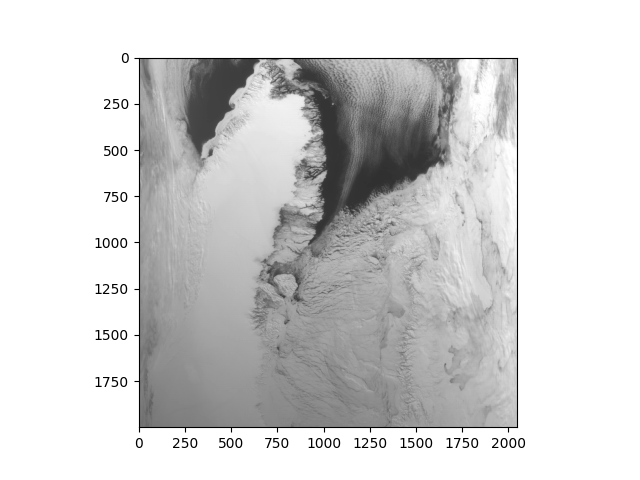

In [3]:
# Оригинальное изображение
img = FY3DImage.get(id=119)
ch_img = img.get_vis_channel(8)
plt.imshow(ch_img, cmap="gray")

In [8]:
# Изменение контраста
contrasted_img = change_contrast(ch_img, 1000, 1300)
plt.imshow(contrasted_img, cmap="gray")

In [5]:
# Применение медианы
median_img = median_filter(ch_img, size=5)
contrasted_median = change_contrast(median_img, 1000, 1300)
plt.imshow(contrasted_median, cmap="gray")

# Применяем к областям

[-0.325904942182169, 0.039503873453768414, 0.002178551017844806]


'\n\n\n'

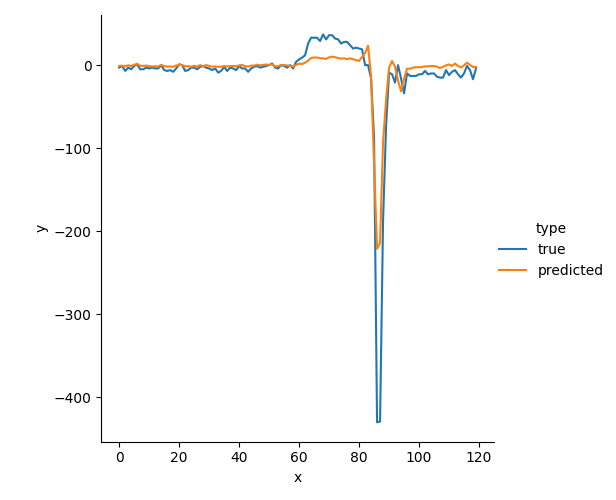

In [7]:
#area_ids = [8917, 8918, 8919, 8920] + [8921, 8922, 8923, 8924, 8925, 8926, 8927, 8928, 8929]
area_ids = [8917]
area, median_values = optimization.connect_areas(area_ids, ch_img)

'''
for sensor in range(0, 10):
    #print("Sensor", sensor)
    coeffs = optimization.optimize(area, median_values, sensor)
    print(f"coeffs[{sensor}, 0:10] =", list(coeffs))
    #print()
'''



sensor = 0
coeffs = optimization.optimize(area, median_values, sensor)
print(list(coeffs))

true_values = area[sensor] - median_values[sensor]
predicted_values = optimization.get_predicted_values(coeffs, area, sensor)

N = len(true_values)
df = pd.DataFrame({
    "x": list(range(N)) * 2,
    "y": list(true_values) + list(predicted_values),
    "type": ["true"] * N + ["predicted"] * N
})
sns.relplot(data=df, x="x", y="y", hue="type", kind="line")
"""


"""